In [18]:
!pip install matplotlib
!pip install torch
!pip install torchvision
!pip install scikit-learn
!pip install seaborn
!pip install ImageHash

   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ------------ --------------------------- 1.3/4.2 MB 7.5 MB/s eta 0:00:01
   ------------------------ --------------- 2.6/4.2 MB 6.8 MB/s eta 0:00:01
   ---------------------------------- ----- 3.7/4.2 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 6.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [PyWavelets]
   ---------------------------------------- 0/2 [PyWavelets]
   ---------------------------------------- 0/2 [PyWavelets]
   ---------------------------------------- 0/2 [PyWavelets]
   -------------------- ------------------- 1/2 [ImageHash]
   ---------------------------------------- 2/2 [ImageHash]



In [9]:
import os
import random
import shutil
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import hashlib

In [10]:
# ==== PATHS ====
DATASET_DIR = Path("data/raw-img")
SPLIT_DIR = Path("data/split")


# ==== DEVICE ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cpu


In [11]:
classes = sorted([p.name for p in DATASET_DIR.iterdir() if p.is_dir()])
print("Classes:", classes)
print("Num classes:", len(classes))

class_counts = {}
for cls in classes:
    cls_path = DATASET_DIR / cls
    images = [f for f in cls_path.iterdir() if f.is_file()]


class_counts

Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Num classes: 10


{'cane': 4863,
 'cavallo': 2623,
 'elefante': 1446,
 'farfalla': 2112,
 'gallina': 3098,
 'gatto': 1668,
 'mucca': 1866,
 'pecora': 1820,
 'ragno': 4821,
 'scoiattolo': 1862}

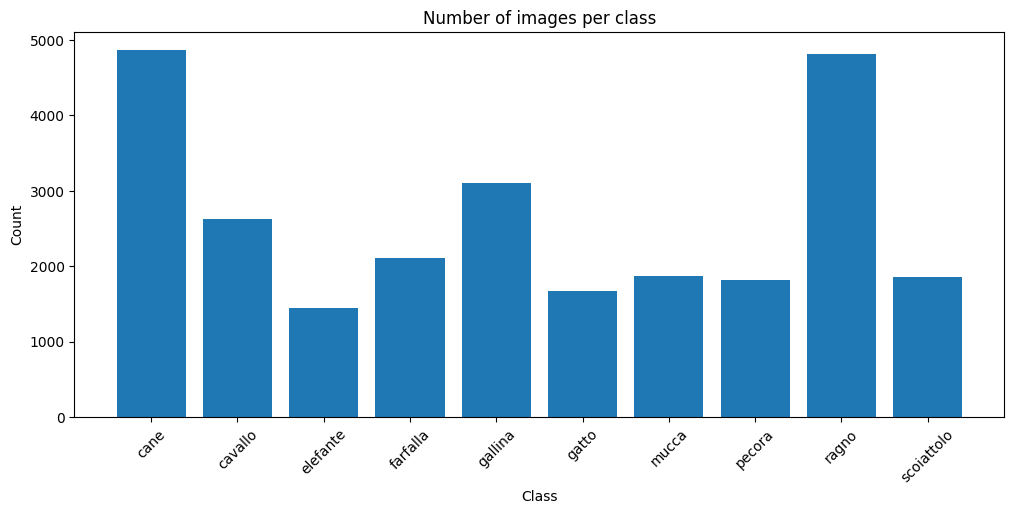

In [6]:
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Number of images per class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [12]:
for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    hashes = set()
    duplicate_found = False

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        with open(img_path, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()

        if h in hashes:
            duplicate_found = True
            break

        hashes.add(h)

    print(cls_dir.name, duplicate_found)

cane False
cavallo False
elefante False
farfalla False
gallina False
gatto False
mucca False
pecora False
ragno False
scoiattolo False


In [16]:
from pathlib import Path
from collections import defaultdict
from PIL import Image
import hashlib
import io

DATASET_DIR = Path("data/raw-img")
TARGET_SIZE = (128, 128)

hash_to_files = defaultdict(list)

for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize(TARGET_SIZE)

            buffer = io.BytesIO()
            img.save(buffer, format="PNG")
            img_hash = hashlib.md5(buffer.getvalue()).hexdigest()

            hash_to_files[img_hash].append((cls_dir.name, img_path.name))

        except Exception as e:
            print(f"Error: {img_path} -> {e}")

found = False

for img_hash, files in hash_to_files.items():
    classes = {cls for cls, _ in files}

    if len(classes) > 1:
        found = True
        print("Duplicate between classes:")
        for cls, filename in files:
            print(f"  {cls} -> {filename}")
        print()

print("Cross-class duplicates found:", found)

Cross-class duplicates found: False


In [17]:
from pathlib import Path
from PIL import Image
import hashlib
import io

DATASET_DIR = Path("data/raw-img")
TARGET_SIZE = (128, 128)

for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    hashes = set()
    duplicate_found = False

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize(TARGET_SIZE)

            buffer = io.BytesIO()
            img.save(buffer, format="PNG")
            h = hashlib.md5(buffer.getvalue()).hexdigest()

            if h in hashes:
                duplicate_found = True
                break

            hashes.add(h)

        except Exception as e:
            print(f"Error: {img_path} -> {e}")

    print(cls_dir.name, duplicate_found)

cane False
cavallo False
elefante False
farfalla False
gallina False
gatto False
mucca False
pecora False
ragno False
scoiattolo False


In [20]:
from pathlib import Path
from PIL import Image
import imagehash
from collections import defaultdict
import json

DATASET_DIR = Path("data/raw-img")
TARGET_SIZE = (128, 128)
MAX_DISTANCE = 4

files_with_hashes = []

for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize(TARGET_SIZE)

            h = imagehash.phash(img)
            files_with_hashes.append((cls_dir.name, img_path.name, h))

        except Exception as e:
            print(f"Error: {img_path} -> {e}")

duplicates = defaultdict(list)

n = len(files_with_hashes)

for i in range(n):
    cls1, file1, hash1 = files_with_hashes[i]
    key = f"{cls1}/{file1}"

    for j in range(i + 1, n):
        cls2, file2, hash2 = files_with_hashes[j]

        if cls1 == cls2:
            continue

        distance = hash1 - hash2

        if distance <= MAX_DISTANCE:
            duplicates[key].append({
                "class": cls2,
                "file": file2,
                "distance": int(distance)
            })

duplicates = dict(duplicates)

output_file = Path("cross_class_duplicates.json")

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(duplicates, f, indent=4)

print("Total images with cross-class duplicates:", len(duplicates))
print("Saved to:", output_file)

Total images with cross-class duplicates: 1
Saved to: cross_class_duplicates.json


In [21]:
print("asigj")

asigj


In [22]:
from pathlib import Path
from PIL import Image

DATASET_DIR = Path("data/raw-img")

deleted = 0

for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            img = Image.open(img_path)
            img.verify()

            img = Image.open(img_path)
            img.load()

        except Exception:
            print("Deleting corrupted:", img_path)
            img_path.unlink()
            deleted += 1

print("Total deleted:", deleted)

Total deleted: 0


In [26]:
from pathlib import Path
from PIL import Image

DATASET_DIR = Path("data/raw-img")

deleted = []
MIN_SIZE = 100

for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            with Image.open(img_path) as img:
                w, h = img.size

            if w < MIN_SIZE or h < MIN_SIZE:
                print(f"Deleting small image: {img_path} ({w}x{h})")
                deleted.append((img_path, w, h))
                img_path.unlink()

        except Exception as e:
            print(f"Error reading {img_path}: {e}")

print("Total deleted:", len(deleted))

with open("too_small_images_deleted.txt", "w") as f:
    for p, w, h in deleted:
        f.write(f"{p} {w}x{h}\n")

Deleting small image: data\raw-img\cavallo\OIP-4UmK-NKWl1fwEK9GfBSGKAAAAA.jpeg (60x57)
Deleting small image: data\raw-img\cavallo\OIP-bT32YLeLizQNLnu4lcVGAAAAAA.jpeg (60x57)
Deleting small image: data\raw-img\cavallo\OIP-jqjnI-BWj-9BkPeqZetiggAAAA.jpeg (60x57)
Deleting small image: data\raw-img\cavallo\OIP-K8QgBSuaAkfMGBB_1C84uQAAAA.jpeg (60x57)
Deleting small image: data\raw-img\cavallo\OIP-zVErTw8mSPohwjPxvw6ehgAAAA.jpeg (60x57)
Deleting small image: data\raw-img\farfalla\OIP-g2ysV7ZtLXJSmzOYfJlKQwAAAA.jpeg (65x64)
Deleting small image: data\raw-img\gallina\OIP-A7HRui5yE2OJlPox5TJe6gAAAA.jpeg (82x96)
Deleting small image: data\raw-img\gallina\OIP-LIe0tzx2fzBlkKbHy3XHVgHaCW.jpeg (300x95)
Deleting small image: data\raw-img\gatto\110.jpeg (120x96)
Deleting small image: data\raw-img\gatto\47.jpeg (300x92)
Deleting small image: data\raw-img\gatto\73.jpeg (120x90)
Deleting small image: data\raw-img\gatto\80.jpeg (120x75)
Deleting small image: data\raw-img\gatto\98.jpeg (120x90)
Deleting sm

In [27]:
from pathlib import Path
from PIL import Image

DATASET_DIR = Path("data/raw-img")

for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    weird = []

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            with Image.open(img_path) as img:
                w, h = img.size
                ratio = max(w / h, h / w)
                if ratio > 3:
                    weird.append((img_path.name, w, h))
        except Exception:
            pass

    print(cls_dir.name, len(weird))
    for item in weird[:10]:
        print(" ", item)

cane 0
cavallo 0
elefante 0
farfalla 0
gallina 0
gatto 0
mucca 0
pecora 0
ragno 0
scoiattolo 0


In [29]:
from pathlib import Path
from PIL import Image, ImageStat

DATASET_DIR = Path("data/raw-img")

for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    removed = 0

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            img = Image.open(img_path).convert("RGB").resize((128, 128))
            stat = ImageStat.Stat(img)
            variance = sum(stat.var) / len(stat.var)

            if variance < 50:
                img_path.unlink()
                removed += 1

        except Exception:
            # якщо файл битий — теж видаляємо
            img_path.unlink()
            removed += 1

    print(cls_dir.name, "removed:", removed)

cane removed: 0
cavallo removed: 0
elefante removed: 0
farfalla removed: 1
gallina removed: 0
gatto removed: 0
mucca removed: 0
pecora removed: 0
ragno removed: 0
scoiattolo removed: 0
